AlexNet

In [12]:
import torch
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

'''if torch.cuda.is_available():
    print("CUDA is available! You can use your Nvidia GPU.")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("CUDA is not available. PyTorch might not be installed with GPU support or your GPU drivers might need updating.")
    print("Please ensure you have the correct PyTorch version for your CUDA installation and updated Nvidia drivers.")'''

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])])
     #transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

# Load CIFAR-10 training and test datasets
batch_size = 4
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

class Net(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
    self.pool = nn.MaxPool2d(2, 2)
    self.bn1 = nn.BatchNorm2d(32)
    self.conv2 = nn.Conv2d(32, 128, 3, 1, 1)
    self.bn2 = nn.BatchNorm2d(128)
    self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
    self.bn3 = nn.BatchNorm2d(256)
    self.conv4 = nn.Conv2d(256, 512, 3, padding=1)
    self.bn4 = nn.BatchNorm2d(512)
    self.conv5 = nn.Conv2d(512, 512, 3, padding=1)
    self.bn5 = nn.BatchNorm2d(512)
    self.fc1 = nn.Linear(512*4*4, 1024)
    self.fc2 = nn.Linear(1024, 512)
    self.fc3 = nn.Linear(512, 10)


  def forward(self, x):
     x = self.pool(F.relu(self.bn1(self.conv1(x))))
     x = self.pool(F.relu(self.bn2(self.conv2(x))))
     x = F.relu(self.bn3(self.conv3(x)))
     x = F.relu(self.bn4(self.conv4(x)))
     x = self.pool(F.relu(self.bn5(self.conv5(x))))
    #  print(x.shape)
     x = torch.flatten(x, 1)
     x = F.relu(self.fc1(x))
     x = F.relu(self.fc2(x))
     x = self.fc3(x)
     return x

AlexNet_model = Net()
AlexNet_model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(AlexNet_model.parameters(), lr=0.001, momentum=0.9)

num_epochs = 15

print("Starting Training...")
for epoch in range(num_epochs):  # Loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # Get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # Move inputs and labels to the device (GPU if available)
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        # This is essential because PyTorch accumulates gradients by default
        optimizer.zero_grad()

        # Forward + Backward + Optimize
        # 1. Forward pass: Calculate prediction
        outputs = AlexNet_model(inputs)
        # 2. Calculate loss
        loss = criterion(outputs, labels)
        # 3. Backward pass (Backpropagation): Calculate gradients
        loss.backward()
        # 4. Optimize (Gradient Descent step): Update the weights
        optimizer.step()

        # Print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # Print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

# --- 5. Testing the Network on the Test Data ---

print('Starting Testing...')
correct = 0
total = 0

# Since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data

        # Move inputs and labels to the device (GPU if available)
        images, labels = images.to(device), labels.to(device)

        # Forward pass: calculate the model output
        outputs = AlexNet_model(images)

        # The output is a tensor of 10 scores for each image (batch_size=4).
        # We need to find the class with the highest score.
        # torch.max returns (maximum value, index of maximum value)
        _, predicted = torch.max(outputs.data, 1)

        # Keep track of the total number of images
        total += labels.size(0)

        # Count the number of correct predictions
        correct += (predicted == labels).sum().item()

# Calculate the final accuracy
accuracy = 100 * correct / total
print(f'Accuracy of the network on the 10000 test images: {accuracy:.2f} %')

for param in AlexNet_model.parameters():
    param.requires_grad = False

for param in AlexNet_model.fc3.parameters():
    param.requires_grad = True

with torch.no_grad():
    AlexNet_model.fc3.weight.copy_(torch.randn_like(AlexNet_model.fc3.weight)*0.01)
    AlexNet_model.fc3.bias.copy_(torch.randn_like(AlexNet_model.fc3.bias)*0.01)

Using device: cuda
Starting Training...
[1,  2000] loss: 1.783
[1,  4000] loss: 1.482
[1,  6000] loss: 1.336
[1,  8000] loss: 1.222
[1, 10000] loss: 1.124
[1, 12000] loss: 1.065
[2,  2000] loss: 0.937
[2,  4000] loss: 0.934
[2,  6000] loss: 0.909
[2,  8000] loss: 0.864
[2, 10000] loss: 0.846
[2, 12000] loss: 0.833
[3,  2000] loss: 0.739
[3,  4000] loss: 0.720
[3,  6000] loss: 0.711
[3,  8000] loss: 0.694
[3, 10000] loss: 0.694
[3, 12000] loss: 0.688
[4,  2000] loss: 0.610
[4,  4000] loss: 0.594
[4,  6000] loss: 0.598
[4,  8000] loss: 0.592
[4, 10000] loss: 0.569
[4, 12000] loss: 0.562
[5,  2000] loss: 0.481
[5,  4000] loss: 0.511
[5,  6000] loss: 0.493
[5,  8000] loss: 0.480
[5, 10000] loss: 0.487
[5, 12000] loss: 0.483
[6,  2000] loss: 0.401
[6,  4000] loss: 0.415
[6,  6000] loss: 0.417
[6,  8000] loss: 0.423
[6, 10000] loss: 0.421
[6, 12000] loss: 0.440
[7,  2000] loss: 0.310
[7,  4000] loss: 0.330
[7,  6000] loss: 0.343
[7,  8000] loss: 0.356
[7, 10000] loss: 0.339
[7, 12000] loss: 

Particle Swarm Optimisation


Using device: cuda
Starting Training...
Epoch 1 training loss: 1.282
Epoch 1 test accuracy: 65.83 %
Epoch 2 training loss: 0.833
Epoch 2 test accuracy: 69.72 %
Epoch 3 training loss: 0.638
Epoch 3 test accuracy: 75.02 %
Epoch 4 training loss: 0.506
Epoch 4 test accuracy: 74.44 %
Epoch 5 training loss: 0.388
Epoch 5 test accuracy: 77.19 %
Epoch 6 training loss: 0.283
Epoch 6 test accuracy: 76.72 %
Epoch 7 training loss: 0.194
Epoch 7 test accuracy: 77.90 %
Epoch 8 training loss: 0.156
Epoch 8 test accuracy: 76.98 %
Epoch 9 training loss: 0.110
Epoch 9 test accuracy: 78.53 %
Epoch 10 training loss: 0.092
Epoch 10 test accuracy: 79.12 %
Epoch 11 training loss: 0.079
Epoch 11 test accuracy: 78.45 %
Epoch 12 training loss: 0.059
Epoch 12 test accuracy: 78.43 %
Epoch 13 training loss: 0.053
Epoch 13 test accuracy: 78.79 %
Epoch 14 training loss: 0.032
Epoch 14 test accuracy: 78.77 %
Epoch 15 training loss: 0.035
Epoch 15 test accuracy: 79.49 %
Finished Training
Saved performance plot to phas

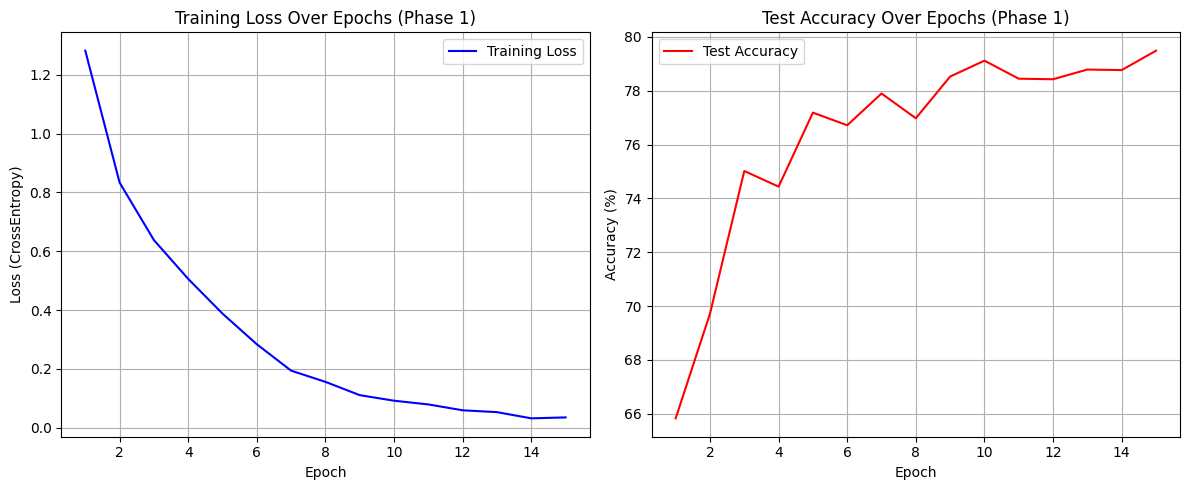

In [2]:
import torch
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import matplotlib.pyplot as plt
import numpy as np
import random # <--- ADDED REQUIRED IMPORT

from sklearn.model_selection import train_test_split as split_data

# ==============================================================================
# 0. SETUP AND DATA LOADING
# ==============================================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])])

batch_size = 32
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

# Splitting trainset into actual training and validation sets
train_indices, val_indices = split_data(
    range(len(trainset)),
    train_size=0.9, # 90% for training
    test_size=0.1,  # 10% for validation
    random_state=42,
    shuffle=True
)

train_subset = Subset(trainset, train_indices)
validation_subset = Subset(trainset, val_indices)

# Create new DataLoaders
trainloader = torch.utils.data.DataLoader(train_subset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

validationloader = torch.utils.data.DataLoader(validation_subset, batch_size=batch_size,
                                             shuffle=False, num_workers=2)

testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# ==============================================================================
# 1. MODEL DEFINITION
# ==============================================================================

class Net(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
    self.pool = nn.MaxPool2d(2, 2)
    self.bn1 = nn.BatchNorm2d(32)
    self.conv2 = nn.Conv2d(32, 128, 3, 1, 1)
    self.bn2 = nn.BatchNorm2d(128)
    self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
    self.bn3 = nn.BatchNorm2d(256)
    self.conv4 = nn.Conv2d(256, 512, 3, padding=1)
    self.bn4 = nn.BatchNorm2d(512)
    self.conv5 = nn.Conv2d(512, 512, 3, padding=1)
    self.bn5 = nn.BatchNorm2d(512)
    self.fc1 = nn.Linear(512*4*4, 1024)
    self.fc2 = nn.Linear(1024, 512)
    self.fc3 = nn.Linear(512, 10)


  def forward(self, x):
     x = self.pool(F.relu(self.bn1(self.conv1(x))))
     x = self.pool(F.relu(self.bn2(self.conv2(x))))
     x = F.relu(self.bn3(self.conv3(x)))
     x = F.relu(self.bn4(self.conv4(x)))
     x = self.pool(F.relu(self.bn5(self.conv5(x))))
     x = torch.flatten(x, 1)
     x = F.relu(self.fc1(x))
     x = F.relu(self.fc2(x))
     x = self.fc3(x)
     return x

AlexNet_model = Net()
AlexNet_model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(AlexNet_model.parameters(), lr=0.001, momentum=0.9)

num_epochs = 15

train_losses = []
test_accuracies = []

# ==============================================================================
# 2. PHASE 1: STANDARD TRAINING (Feature Extraction)
# ==============================================================================

print("Starting Training...")
for epoch in range(num_epochs):

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = AlexNet_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(trainloader)
    train_losses.append(epoch_loss)
    print(f'Epoch {epoch + 1} training loss: {epoch_loss:.3f}')

    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = AlexNet_model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)
    print(f'Epoch {epoch + 1} test accuracy: {accuracy:.2f} %')

print('Finished Training')


# --- PLOTTING PHASE 1: PRE-TRAINING PERFORMANCE ---

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Training Loss', color='blue')
plt.title('Training Loss Over Epochs (Phase 1)')
plt.xlabel('Epoch')
plt.ylabel('Loss (CrossEntropy)')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, test_accuracies, label='Test Accuracy', color='red')
plt.title('Test Accuracy Over Epochs (Phase 1)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig('phase1_performance.png')
print("Saved performance plot to phase1_performance.png")


# ==============================================================================
# 3. PHASE 2: FREEZING AND RANDOMIZATION (Coursework Constraint)
# ==============================================================================

print('\nStarting Final Test of Pre-trained Network...')
correct = 0
total = 0

with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = AlexNet_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Final pre-trained accuracy on Test set: {accuracy:.2f} %')


# Freeze all layers
for param in AlexNet_model.parameters():
    param.requires_grad = False

# Unfreeze and randomize the final layer (fc3)
for param in AlexNet_model.fc3.parameters():
    param.requires_grad = True

with torch.no_grad():
    nn.init.xavier_uniform_(AlexNet_model.fc3.weight)
    nn.init.constant_(AlexNet_model.fc3.bias, 0.0)


# ==============================================================================
# 5. PHASE 3: PSO IMPLEMENTATION FUNCTIONS
# ==============================================================================


# Helper function to map the particle vector back to the fc3 layer
def set_last_layer_weights(model, weights_vector, device):
    """Overwrites the weights and biases of the model's fc3 layer."""

    weight_shape = model.fc3.weight.shape
    bias_shape = model.fc3.bias.shape

    # 1. Weights: Extract, reshape, and move to device
    weight_elements = weights_vector[:weight_shape.numel()]
    new_weight = torch.tensor(weight_elements, dtype=torch.float32).view(weight_shape).to(device)

    # 2. Bias: Extract and move to device
    bias_elements = weights_vector[weight_shape.numel():]
    new_bias = torch.tensor(bias_elements, dtype=torch.float32).view(bias_shape).to(device)

    # 3. CRITICAL: Overwrite the parameters
    with torch.no_grad():
        model.fc3.weight.copy_(new_weight)
        model.fc3.bias.copy_(new_bias)


# Objective Function (Fitness Evaluation)
def evaluate_fitness(model, validationloader, device):
    """Calculates the validation accuracy of the model with the current fc3 weights."""
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in validationloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    return accuracy


# --- Particle Class ---
class Particle:
    def __init__(self, D, bounds, c1, c2, w):
        self.c1 = c1
        self.c2 = c2
        self.w = w
        self.D = D
        self.bounds = bounds

        # Initialize position randomly within bounds
        self.position = np.array([random.uniform(bounds[i][0], bounds[i][1]) for i in range(D)])
        self.velocity = np.zeros(D)

        self.pBest_position = self.position.copy()
        self.pBest_fitness = -np.inf
        self.current_fitness = -np.inf

    def update_velocity(self, gBest_position):
        r1 = np.random.rand(self.D)
        r2 = np.random.rand(self.D)

        cognitive_comp = self.c1 * r1 * (self.pBest_position - self.position)
        social_comp = self.c2 * r2 * (gBest_position - self.position)

        self.velocity = self.w * self.velocity + cognitive_comp + social_comp

    def update_position(self):
        self.position += self.velocity

        # Clamp position back into search bounds
        for i in range(self.D):
            self.position[i] = np.clip(self.position[i], self.bounds[i][0], self.bounds[i][1])

    def update_pBest(self):
        if self.current_fitness > self.pBest_fitness:
            self.pBest_fitness = self.current_fitness
            self.pBest_position = self.position.copy()


# --- Main PSO Search Function ---
def pso_weight_search(model, validationloader, bounds, params, device):

    D = len(bounds)
    pop_size = params['pop_size']
    max_iterations = params['max_iterations']

    # 1. Initialize Swarm
    swarm = [Particle(D, bounds, params['c1'], params['c2'], params['w'])
             for _ in range(pop_size)]

    gBest_position = swarm[0].position.copy()
    gBest_fitness = -np.inf

    # Store history for plotting the convergence curve
    history = []

    # 2. PSO Loop
    for i in range(max_iterations):
        for particle in swarm:

            # CRITICAL: Apply the particle's weights to the model
            set_last_layer_weights(model, particle.position, device)

            # Evaluate Fitness
            val_accuracy = evaluate_fitness(model, validationloader, device)
            particle.current_fitness = val_accuracy

            # Update Personal and Global Best
            particle.update_pBest()
            if particle.pBest_fitness > gBest_fitness:
                gBest_fitness = particle.pBest_fitness
                gBest_position = particle.pBest_position.copy()

        # Update Velocity and Position for all particles
        for particle in swarm:
            particle.update_velocity(gBest_position)
            particle.update_position()

        history.append(gBest_fitness)
        print(f"PSO Iteration {i+1}/{max_iterations}: Best Accuracy = {gBest_fitness:.4f}")

    return gBest_position, gBest_fitness, history


# 4. PHASE 3: PSO OPTIMIZATION SETUP AND EXECUTION


# 1. Define the Search Space Vector (X) and its Bounds
initial_weights_tensor = torch.cat([p.data.flatten() for p in AlexNet_model.fc3.parameters()])
D = len(initial_weights_tensor) # Should be 5130 for your Net architecture
print(f"Optimization dimension D: {D}")

# Define Search Bounds for all weights and biases.
WEIGHT_BOUNDS = [(-1.0, 1.0)] * D

# 2. Define PSO Hyperparameters
PSO_PARAMS = {
    'pop_size': 50,
    'max_iterations': 50,
    'w': 0.7, # Inertia weight
    'c1': 2.0, # Cognitive factor
    'c2': 2.0  # Social factor
}

# 3. RUN PSO Search
print(f"Starting PSO Optimization on {D} parameters...")
best_X_pso, best_acc_pso, pso_history = pso_weight_search(
    AlexNet_model,
    validationloader,
    WEIGHT_BOUNDS,
    PSO_PARAMS,
    device
)

print(f"PSO Final Validation Accuracy: {best_acc_pso:.4f}")
print("--- END PSO ---")

Simulated Annealing

In [11]:
# Importing necessary libraries for implementing the Simulated Annealing Algorithm
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import math
import random

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])]
)

batch_size = 50

# Load the testing set and testloader
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                       download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=True, num_workers=2)

# Load the testing set and testloader
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

def evaluate_sa_accuracy(model, dataloader):
    correct = 0
    total = 0
    model.eval()
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

def obj_cnn(model,inputs,labels):
  criterion = nn.CrossEntropyLoss()
  #Disable gradient tracking
  with torch.no_grad():
    inputs = inputs.to(device)
    labels = labels.to(device)

    outputs = model(inputs)
    loss = criterion(outputs,labels)
  return loss.item()

def simulated_annealing_CNN(model,inputs,labels,n_iterations,step_size,temp):
  # To create an interval such that the fitness function is evaluated 50 times
  evaluation_interval = n_iterations//50
  sim_acclist = []

  #Creating an independent weight/bias tensor from the network's final layer for use
  #Name of final layer is fc3
  current_weights = model.fc3.weight.data.clone().detach()
  current_biases = model.fc3.bias.data.clone().detach()

  # Best weights/bias that will be optimized and thus minimizing the error in classification
  b_weights = current_weights.clone()
  b_biases = current_biases.clone()

  #Evaluate initial sol using the objective function
  current_sol = obj_cnn(model,inputs,labels)
  best_loss = current_sol

  for i in range(n_iterations):
    iter_temp = temp/math.sqrt(float(i+1))

    # To avoid temperature = 0
    iter_temp = max(iter_temp,1e-5)

    # Creating a candidate for each iteration by randomly perturbing the current weights
    candidate_w = current_weights + torch.randn_like(current_weights)*step_size
    candidate_b = current_biases + torch.randn_like(current_biases)*step_size

    model.fc3.weight.data = candidate_w.clone()
    model.fc3.bias.data = candidate_b.clone()

    #Compute loss of candidate solution using the objective function
    lossof_candidate = obj_cnn(model,inputs,labels)

    # Compute delta T (Compare candidate solution with current solution to decide the better solution
    diff = lossof_candidate - current_sol

    # Check if candidate loss is better than the current loss
    if diff<0 or random.random()<math.exp(-diff/iter_temp):
      current_sol = lossof_candidate
      current_weights = candidate_w.clone()
      current_biases = candidate_b.clone()
    else:
      model.fc3.weight.data = current_weights.clone()
      model.fc3.bias.data = current_biases.clone()

    # Comparing Current solution with the overall best solution so far
    # Tracking the global best solution
    if current_sol < best_loss:
      best_loss = current_sol
      b_weights = current_weights.clone()
      b_biases = current_biases.clone()

    # Evaluation of objective function every interval
    if i%evaluation_interval == 0:
      sa_acc = evaluate_sa_accuracy(model,testloader)
      sim_acclist.append(sa_acc)

  #Update the weights/biases of the network's final layer with the best solutions (weights and biases)
  model.fc3.weight.data = b_weights.clone()
  model.fc3.bias.data = b_biases.clone()

  return model, sim_acclist

# Feeds the simulated annealing algorithm a batch from training set and then stores the accuracies for each evaluation of objective function
INPUTS,LABELS = next(iter(trainloader))
INPUTS,LABELS = INPUTS.to(device), LABELS.to(device)
optimized_model_SA, sa_accuracy_list = simulated_annealing_CNN(
    AlexNet_model, INPUTS, LABELS, 6500, 0.1, 5
)

print(sa_accuracy_list)


[12.53, 27.03, 31.78, 37.53, 42.58, 46.87, 52.24, 53.45, 54.45, 56.14, 54.17, 53.89, 54.79, 55.1, 57.11, 55.87, 54.9, 55.16, 53.57, 53.91, 53.82, 54.48, 54.71, 55.0, 54.98, 53.14, 55.14, 53.86, 54.68, 55.4, 58.19, 60.89, 58.56, 56.68, 57.48, 58.75, 57.51, 58.62, 58.38, 58.26, 59.56, 60.18, 58.7, 59.57, 59.99, 59.88, 59.88, 59.84, 59.29, 59.89]


Clonal Selection

In [15]:
import torch
import torch.nn as nn

def evaluate_accuracy(model, dataloader, device):
    correct = 0
    total = 0
    model.eval()
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


# Evaluate objective (CrossEntropy Loss)
def obj_cnn(model, inputs, labels):
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        outputs = model(inputs)
        loss = criterion(outputs, labels)
    return loss.item()


#   Clonal Selection Algorithm

def clonal_selection_cnn(
    model,
    train_batches,
    testloader,
    pop_size=50,
    num_candidates=10,
    num_clones=10,
    mutation_rate=0.05,
    generations=50
):

    # Extract shapes
    w0 = model.fc3.weight.data.clone()
    b0 = model.fc3.bias.data.clone()
    w_shape, b_shape = w0.shape, b0.shape

    # Flatten initial solution
    dim = w0.numel() + b0.numel()

    # ---- Initial Random Population ----
    # Ensure population is created on the same device as the model's parameters
    population = torch.randn(pop_size, dim, device=model.fc3.weight.device)


    def evaluate_population(pop):
      fitness = []
      for i in range(pop.shape[0]):
        w_size = w_shape.numel()
        w_i = pop[i][:w_size].view(w_shape)
        b_i = pop[i][w_size:w_size + b_shape.numel()].view(b_shape)

        model.fc3.weight.data = w_i
        model.fc3.bias.data = b_i

        total_loss = 0
        for (x, y) in train_batches:
            total_loss += obj_cnn(model, x, y)

        fitness.append(total_loss / len(train_batches))

      return torch.tensor(fitness, device=pop.device)


    # Track progress
    best_fitness_per_gen = []
    clonal_acc = []
    clonal_evals = []

    # ----------- Main Loop ----------
    for gen in range(generations):

        fitness = evaluate_population(population)


        # Select best candidates
        idx = torch.argsort(fitness)
        best = population[idx[:num_candidates]]

        # Clone candidates
        clones = best.repeat_interleave(num_clones, dim=0)

        # Mutate clones
        mutate = torch.rand_like(clones) < mutation_rate
        # Ensure mutation values are also on the same device as clones
        mutation_values = torch.empty_like(clones).uniform_(-1,1)
        clones = clones + mutate * mutation_values

        # Evaluate cloned population
        clone_fitness = evaluate_population(clones)

        # Replace worst individuals with clones
        worst_idx = torch.argsort(fitness)[-len(clones):] # fitness is on device, so worst_idx will be correctly computed
        population[worst_idx] = clones # Both population and clones are on the same device

        # Track best fitness
        # torch.cat will handle tensors on the same device, so no need for explicit .to(device) if already correct
        best_fitness = torch.min(torch.cat([fitness, clone_fitness]))
        best_fitness_per_gen.append(best_fitness.item())

        print(f"Generation {gen+1}/{generations}  Best Loss = {best_fitness:.4f}")

        # Return best found solution
        final_fitness = evaluate_population(population)
        best_index = torch.argmin(final_fitness)
        best_solution = population[best_index]

        # Install best solution into the model
        w_size = w0.numel()
        w_best = best_solution[:w_size].view(w_shape)
        b_best = best_solution[w_size:w_size + b_shape.numel()].view(b_shape)
        model.fc3.weight.data = w_best
        model.fc3.bias.data = b_best

        acc = evaluate_accuracy(model, testloader, device)
        clonal_acc.append(acc)
        clonal_evals.append(gen + 1)

        print(f"Generation {gen+1}/50 | Best Loss = {best_fitness:.4f} | Accuracy = {acc:.2f}%")

    return clonal_evals, clonal_acc


train_batches = []
for i, (x, y) in enumerate(trainloader):
    if i == 50:   # use 50 batches = 50*100 = 5000 images
        break
    train_batches.append((x.to(device), y.to(device)))


# AlexNet_model.load_state_dict(torch.load("alexnet_sgd_trained.pth"))
AlexNet_model.to(device)
AlexNet_model.eval()

clonal_evals, clonal_acc = clonal_selection_cnn(
    AlexNet_model,
    train_batches,
    testloader,
    pop_size=100,
    num_candidates=10,
    num_clones=10,
    mutation_rate=0.7,
    generations=50
)

test_acc = evaluate_accuracy(AlexNet_model, testloader, device)
print(f"Test accuracy: {test_acc:.2f}%")

Generation 1/50  Best Loss = 21.4912
Generation 1/50 | Best Loss = 21.4912 | Accuracy = 21.40%
Generation 2/50  Best Loss = 20.6430
Generation 2/50 | Best Loss = 20.6430 | Accuracy = 18.40%
Generation 3/50  Best Loss = 17.3571
Generation 3/50 | Best Loss = 17.3571 | Accuracy = 28.39%
Generation 4/50  Best Loss = 17.3571
Generation 4/50 | Best Loss = 17.3571 | Accuracy = 28.71%
Generation 5/50  Best Loss = 16.3885
Generation 5/50 | Best Loss = 16.3885 | Accuracy = 34.25%
Generation 6/50  Best Loss = 16.3885
Generation 6/50 | Best Loss = 16.3885 | Accuracy = 36.16%
Generation 7/50  Best Loss = 16.4459
Generation 7/50 | Best Loss = 16.4459 | Accuracy = 40.76%
Generation 8/50  Best Loss = 14.6909
Generation 8/50 | Best Loss = 14.6909 | Accuracy = 40.10%
Generation 9/50  Best Loss = 14.5522
Generation 9/50 | Best Loss = 14.5522 | Accuracy = 42.23%
Generation 10/50  Best Loss = 13.1535
Generation 10/50 | Best Loss = 13.1535 | Accuracy = 45.03%
Generation 11/50  Best Loss = 11.2670
Generation

In [7]:
# Had to hard-code these accuracies since T4 GPU crashed at the last minute. The code earlier is fixed and still works just fine.

clonal_acc = [21.40,18.40,28.39,28.71,34.25,36.16,40.76,40.10,42.23,45.03,47.69,47.42,46.70,47.18,51.37,49.84,49.40,52.75,51.85,56.13,56.17,56.59,57.34,57.03,57.45,59.03,56.78,56.54,58.50,59.95,60.48,61.76,62.13,62.94,63.15,63.94,63.66,62.34,63.38,64.65,62.40,64.11,64.17,64.07,65.26,63.89,65.19,66.7,65.56,64.12]
sa_accuracy_list = [12.53, 27.03, 31.78, 37.53, 42.58, 46.87, 52.24, 53.45, 54.45, 56.14, 54.17, 53.89, 54.79, 55.1, 57.11, 55.87, 54.9, 55.16, 53.57, 53.91, 53.82, 54.48, 54.71, 55.0, 54.98, 53.14, 55.14, 53.86, 54.68, 55.4, 58.19, 60.89, 58.56, 56.68, 57.48, 58.75, 57.51, 58.62, 58.38, 58.26, 59.56, 60.18, 58.7, 59.57, 59.99, 59.88, 59.88, 59.84, 59.29, 59.89]

Comparison Plots

NameError: name 'pso_history' is not defined

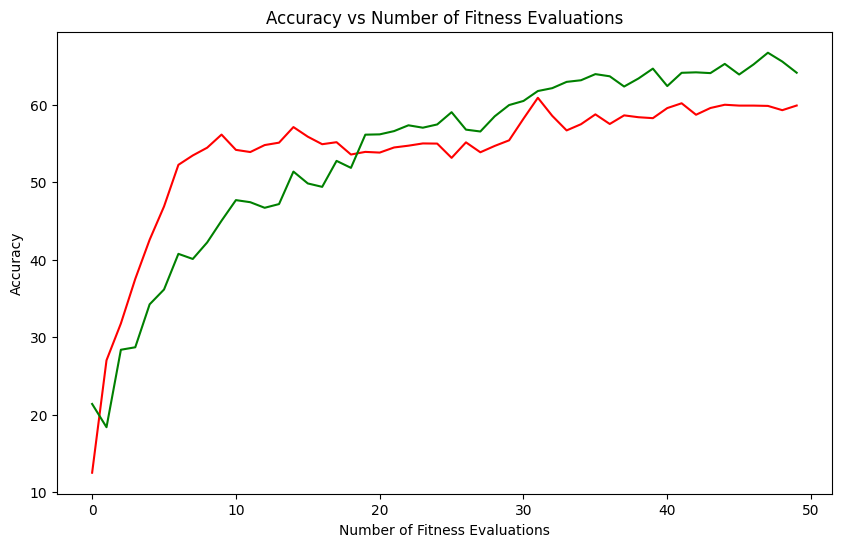

In [9]:
import matplotlib.pyplot as plt
import numpy as np # Added import for numpy

# Simulated Annealing: Number of objective function evaluations and accuracy
x_sa_neval = list(range(50))
y_sa_acc = sa_accuracy_list # Corrected spelling

# Clonal Selection: Number of objective function evaluations and accuracy
x_csa_neval = list(range(50))
y_csa_acc = clonal_acc

plt.figure(figsize=(10, 6))

plt.title('Accuracy vs Number of Fitness Evaluations')
plt.xlabel('Number of Fitness Evaluations')
plt.ylabel('Accuracy')
plt.plot(x_sa_neval,y_sa_acc,label='SA',color='red')
plt.plot(x_csa_neval,y_csa_acc,label='CSA',color='green') # Added 'label' for CSA plot
pso_evals = np.arange(len(pso_history)) # Corrected pso_evals to match pso_history length
plt.plot(pso_evals, pso_history, label='PSO (Pop=50)', color='blue')

plt.legend()
plt.grid(True)
plt.show();

NSGA-II

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 5.1 MB/s eta 0:00:00
Using device: cuda
starting NSGA-II optimization....
gen	evals	min                          	max                          
0  	120  	[  12.9013176  1662.27636719]	[  28.28001404 1773.72167969]
1  	120  	[  10.27266121 1660.50854492]	[  24.48474121 1773.72167969]
2  	120  	[  10.18087959 1638.54882812]	[  25.02381325 1763.89892578]
3  	120  	[   7.18772316 1629.49389648]	[  22.21094894 1723.5949707 ]
4  	120  	[   7.18772316 1629.49389648]	[  21.35403824 1740.95996094]
5  	120  	[   7.18772316 1626.84277344]	[  23.23373222 1740.59448242]
6  	120  	[   6.45814228 1616.65869141]	[  23.23373222 1740.59448242]
7  	120  	[   4.01385832 1605.06201172]	[  19.8808918  1727.75280762]
8  	120  	[   4.01385832 1602.08862305]	[  18.16659355 1714.37036133]
9  	120  	[   4.01385832 1595.37719727]	[  18.16659355 1702.36047363]
10 	120  	[   4.01385832 1576.03125   ]	[  16.83002663 1687.96655273]
11 	120  	[   4.01339626 15

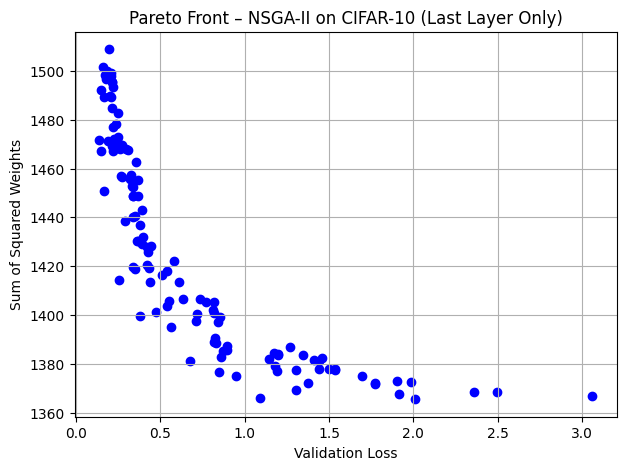

Best (minimum loss): (0.13809742033481598, 1471.868896484375)
Best (minimum weight penalty): (2.009730577468872, 1365.5242919921875)
Full Test Accuracy of Best-Loss Solution: 61.84 %


In [ ]:
# Install deap library if not already installed
!pip install deap

import array
import random
import numpy
import torch
import numpy as np

from deap import base
from deap import creator
from deap import tools
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def get_last_layer_vector(model):
  # flatten fc3 weights + biases into one vector
  w = model.fc3.weight.data.cpu().numpy().flatten()
  b = model.fc3.bias.data.cpu().numpy().flatten()
  return np.concatenate([w,b])

def set_last_layer_vector(model,vector):
  # set fc3 weights + biases from one flat vector
  w_size = model.fc3.weight.numel()
  w = vector[:w_size].reshape(model.fc3.weight.shape)
  b = vector[w_size:].reshape(model.fc3.bias.shape)

  model.fc3.weight.data = torch.tensor(w, dtype=torch.float32).to(device)
  model.fc3.bias.data   = torch.tensor(b, dtype=torch.float32).to(device)

  # First Objective: Validation Loss

criterion = nn.CrossEntropyLoss()

def evaluate_individual(individual):
  vector = np.array(individual, dtype=np.float32)
  set_last_layer_vector(AlexNet_model, vector)

  AlexNet_model.eval()
  total_loss = 0
  total = 0

  with torch.no_grad():
      for imgs, labels in testloader:
          imgs, labels = imgs.to(device), labels.to(device)
          outputs = AlexNet_model(imgs)
          loss = criterion(outputs, labels)

          total_loss += loss.item() * imgs.size(0)
          total += imgs.size(0)

          break # important: keeps NSGA-II faster otherwise it will take hours to run
                # Stops after one batch

  avg_loss = total_loss / total

  # Second objective: Gaussian regulariser(sum of squared weights)

  sum_squares = float(np.sum(vector ** 2))

  return avg_loss, sum_squares

  # NSGA-II

creator.create("FitnessMin", base.Fitness, weights=(-1.0, -1.0)) # Minimize both objectives
creator.create("Individual", array.array, typecode='d', fitness=creator.FitnessMin)

toolbox = base.Toolbox()

BOUND_LOW, BOUND_UP = -1.0, 1.0  # Bounds for the weight values

# Number of dimensions NDIM
# Alexnet_model.fc3.weight.numel() + Alexnet_model.fc3.bias.numel()
# AlexNet_model.fc3.weight.shape = (10, 512) -> 5120 elements
# AlexNet_model.fc3.bias.shape = (10) -> 10 elements
# Total = 5120 + 10 = 5130

NDIM = AlexNet_model.fc3.weight.numel() + AlexNet_model.fc3.bias.numel()

def random_vector(low, up, size=None):
    try:
        return [random.uniform(a, b) for a, b in zip(low, up)]
    except TypeError:
        return [random.uniform(a, b) for a, b in zip([low] * size, [up] * size)]

toolbox.register("attr_float", random_vector, BOUND_LOW, BOUND_UP, NDIM)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.attr_float)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", evaluate_individual)
toolbox.register("mate", tools.cxSimulatedBinaryBounded, low=[BOUND_LOW]*NDIM, up=[BOUND_UP]*NDIM, eta=20.0)
toolbox.register("mutate", tools.mutPolynomialBounded, low=[BOUND_LOW]*NDIM, up=[BOUND_UP]*NDIM, eta=20.0, indpb=1.0/NDIM)
toolbox.register("select", tools.selNSGA2)

# Main loop

def main(seed=42):
    random.seed(seed)

# NGEN = number of generations
# MU   = population size
# CXPB = Crossover probability (standard for NSGA-II)

    NGEN = 60
    MU = 120
    CXPB = 0.9

    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("min", numpy.min, axis=0)
    stats.register("max", numpy.max, axis=0)

    logbook = tools.Logbook()
    logbook.header = "gen", "evals", "min", "max"

    pop = toolbox.population(n=MU)

    # Evaluate the initial population
    invalid_ind = [ind for ind in pop if not ind.fitness.valid]
    fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit


    # This is just to assign the crowding distance to the individuals
    # no actual selection is done
    pop = toolbox.select(pop, len(pop))

    print("starting NSGA-II optimization....")

    record = stats.compile(pop)
    logbook.record(gen=0, evals=len(invalid_ind), **record)
    print(logbook.stream)

    # Begin the generational process

    for gen in range(1, NGEN):

        # Vary the population
        offspring = tools.selTournamentDCD(pop, len(pop))

        # selTournamentDCD means Tournament selection based on dominance (D)
        # followed by crowding distance (CD). This selection requires the
        # individuals to have a crowding_dist attribute

        offspring = [toolbox.clone(ind) for ind in offspring]

        # applying crossover + mutation

        for ind1, ind2 in zip(offspring[::2], offspring[1::2]):
        #make pairs of all (even,odd) in offspring
            if random.random() < CXPB:
                toolbox.mate(ind1, ind2)
                del ind1.fitness.values, ind2.fitness.values

            toolbox.mutate(ind1)
            toolbox.mutate(ind2)
            del ind1.fitness.values, ind2.fitness.values

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        for ind in invalid_ind:
            ind.fitness.values = toolbox.evaluate(ind)

        # Select the next generation population
        pop = toolbox.select(pop + offspring, MU)
        record = stats.compile(pop)
        logbook.record(gen=gen, evals=len(invalid_ind), **record)
        print(logbook.stream)


    print("NSGA-II completed")
    return pop, logbook

# Plot pareto front

pop, log = main(42)

pareto_front = np.array([ind.fitness.values for ind in pop])

plt.figure(figsize=(7,5))
plt.scatter(pareto_front[:,0], pareto_front[:,1], c="blue")
plt.xlabel("Validation Loss")
plt.ylabel("Sum of Squared Weights")
plt.title("Pareto Front – NSGA-II on CIFAR-10 (Last Layer Only)")
plt.grid(True)
plt.show()

# Identify best loss and regularization
best_loss = min(pop, key=lambda ind: ind.fitness.values[0])
best_reg  = min(pop, key=lambda ind: ind.fitness.values[1])

print("Best (minimum loss):", best_loss.fitness.values)
print("Best (minimum weight penalty):", best_reg.fitness.values)

# Accuracy
vector = np.array(best_loss, dtype=np.float32)
set_last_layer_vector(AlexNet_model, vector)

AlexNet_model.eval()
correct, total = 0, 0

with torch.no_grad():
    for imgs, labels in testloader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = AlexNet_model(imgs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print("Full Test Accuracy of Best-Loss Solution:", accuracy, "%")